In [18]:
import os

import pandas as pd

import data_util
import duckdb
import plot_util
import pyarrow.parquet as pq
import seaborn as sns
import wandb
import sys
import json
import numpy as np
import sys

In [19]:
data_root = os.path.abspath("./data/wandb")
group = "ersac_testing"
# group = "vlite_testing"
project = "jamesr-j/BSuite_Testing"

if os.path.exists(os.path.join(data_root, group)):
    api = wandb.Api(timeout=2000)
    runs = api.runs(project, filters={"group": group})
    assert runs
    save_dir = os.path.join(data_root, group)
    os.makedirs(save_dir, exist_ok=True)
    data_util.write_runs_to_parquet(runs, save_dir)

file_glob = os.path.join(data_root, group)  # , "*.parquet")

def read_wandb_metadata(path: os.PathLike, filename: bool = True):
    parquet_metadata = pq.read_metadata(path)
    wandb_metadata = json.loads(parquet_metadata.metadata[b"wandb"])
    if filename:
        wandb_metadata["filename"] = os.fspath(path)
    return wandb_metadata

all_dicts = []
for file in os.listdir(file_glob):
    meta_step = data_util.read_wandb_metadata(os.path.join(file_glob, file))
    all_dicts.append(meta_step)
meta = pd.DataFrame(all_dicts)

meta["config"] = meta["config"].apply(lambda row: row['_fields'])  # TODO added this line cus different config saving whoops

### below is dodgy workaround when differeing lengths config, to keep the struct datatype in duckdb
max_keys = 0
max_keys_id = None
for row_id in range(len(meta["config"])):
    length = len(meta["config"][row_id])
    if length > max_keys:
        max_keys = length
        max_keys_id = row_id
all_keys = meta["config"][max_keys_id].keys()

def update_dict(d):
  return {key: d.get(key, np.nan) for key in all_keys}

meta["config"] = meta["config"].apply(update_dict)
### and here it ends

metrics = data_util.read_wandb_history(os.path.join(file_glob, "*.parquet"))
measurements = duckdb.from_df(meta.loc[:, ["id", "config"]]).join(metrics, "id")

Skip writing runs.


[28]
['ERSAC']
[10]
[1.  0.6 0.8]
[2.e+00 1.e-01 1.e+02 1.e+00 1.e+01 1.e-02]


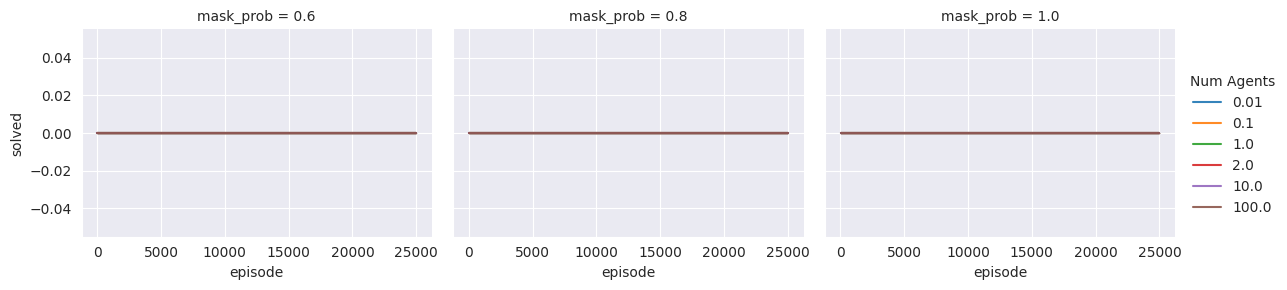

In [23]:
data = measurements.project("""
id as id,
config.seed as seed,
config.algo as algo,
config.uncertainty_scale as uncertainty_scale,
config.mask_prob as mask_prob,
config.deep_sea_map as deep_sea_map,
"episode" as episode,
"solved" as solved
"""
).filter("algo == 'ERSAC' and deep_sea_map == 10 and seed == 28")  

colours = sns.color_palette("husl", 8)[5:8:2]

print(data.df().dropna(how='any',axis=0)["seed"].unique())
print(data.df().dropna(how='any',axis=0)["algo"].unique())
print(data.df().dropna(how='any',axis=0)["deep_sea_map"].unique())
print(data.df().dropna(how='any',axis=0)["mask_prob"].unique())
print(data.df().dropna(how='any',axis=0)["uncertainty_scale"].unique())

g = sns.FacetGrid(
    data.df().dropna(how='any',axis=0),
    col="mask_prob",
    hue="uncertainty_scale",
    # palette = colours,
    sharey='row',
    sharex=True,
    aspect=1/0.75,
)

g.map(plot_util.smoothed_lineplot, "episode", "solved", num_std=1, span=0.0015)
# g.set_axis_labels("Episodes", "Solved")
# g.set_titles("")
g.add_legend(title="Num Agents")
# g.savefig("../figures/homo_tests.svg")

In [2]:
data_root = os.path.abspath("./data/wandb")
# group = "ersac_testing"
group = "vlite_testing"
project = "jamesr-j/BSuite_Testing"

# if not os.path.exists(os.path.join(data_root, group)):
if os.path.exists(os.path.join(data_root, group)):
    api = wandb.Api(timeout=2000)
    runs = api.runs(project, filters={"group": group})
    assert runs
    save_dir = os.path.join(data_root, group)
    os.makedirs(save_dir, exist_ok=True)
    data_util.write_runs_to_parquet(runs, save_dir)
    # for run in runs:
    #     table = data_util._run_to_arrow_table(run, save_metadata=True)
    #     save_path = os.path.join(save_dir, f"{run.id}.parquet")
    #     print("Saving", save_path)
    #     pq.write_table(table, save_path)

file_glob = os.path.join(data_root, group)  # , "*.parquet")

def read_wandb_metadata(path: os.PathLike, filename: bool = True):
    parquet_metadata = pq.read_metadata(path)
    wandb_metadata = json.loads(parquet_metadata.metadata[b"wandb"])
    if filename:
        wandb_metadata["filename"] = os.fspath(path)
    return wandb_metadata

all_dicts = []
for file in os.listdir(file_glob):
    meta_step = data_util.read_wandb_metadata(os.path.join(file_glob, file))
    all_dicts.append(meta_step)
meta = pd.DataFrame(all_dicts)

meta["config"] = meta["config"].apply(lambda row: row['_fields'])  # TODO added this line cus different config saving whoops
# print(meta)
# sys.exit()

### below is dodgy workaround when differeing lengths config, to keep the struct datatype in duckdb
max_keys = 0
max_keys_id = None
for row_id in range(len(meta["config"])):
    length = len(meta["config"][row_id])
    if length > max_keys:
        max_keys = length
        max_keys_id = row_id
all_keys = meta["config"][max_keys_id].keys()

def update_dict(d):
  return {key: d.get(key, np.nan) for key in all_keys}

meta["config"] = meta["config"].apply(update_dict)
### and here it ends

# meta = data_util.read_wandb_metadata(file_glob)  # TODO this is the original
metrics = data_util.read_wandb_history(os.path.join(file_glob, "*.parquet"))
# measurements = duckdb.from_df(meta.loc[:, ["id", *meta.attrs["sweep_vars"]]]).join(metrics, "id")  # TODO the original

measurements = duckdb.from_df(meta.loc[:, ["id", "config"]]).join(metrics, "id")
# measurements = duckdb.from_df(meta.loc[:, ["id"]]).join(metrics, "id")

# measurements["_step"]
# measurements["config"]
# measurements.columns

Skip writing runs.


[98]
['VLITE']
[4]
[1.  0.8 0.6]
[1.e+01 2.e+00 1.e+02 1.e-02]


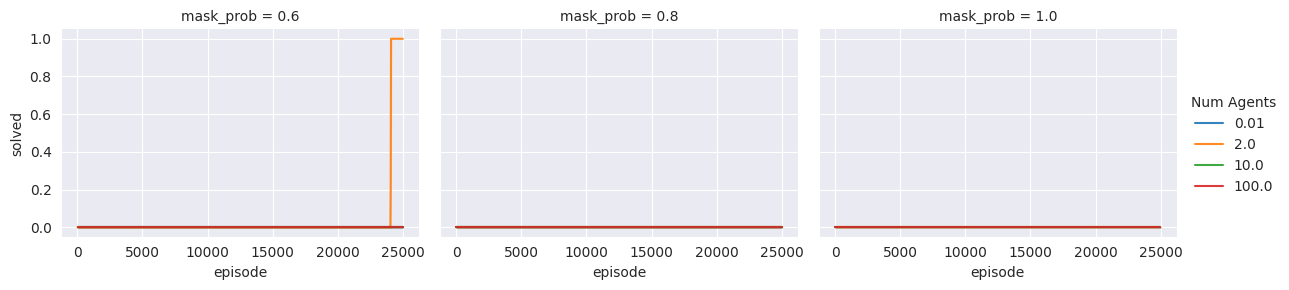

In [8]:
data = measurements.project("""
id as id,
config.seed as seed,
config.algo as algo,
config.uncertainty_scale as uncertainty_scale,
config.mask_prob as mask_prob,
config.deep_sea_map as deep_sea_map,
"episode" as episode,
"solved" as solved
"""
).filter("algo == 'VLITE' and deep_sea_map == 4 and seed == 98")  

colours = sns.color_palette("husl", 8)[5:8:2]

print(data.df().dropna(how='any',axis=0)["seed"].unique())
print(data.df().dropna(how='any',axis=0)["algo"].unique())
print(data.df().dropna(how='any',axis=0)["deep_sea_map"].unique())
print(data.df().dropna(how='any',axis=0)["mask_prob"].unique())
print(data.df().dropna(how='any',axis=0)["uncertainty_scale"].unique())

g = sns.FacetGrid(
    data.df().dropna(how='any',axis=0),
    col="mask_prob",
    hue="uncertainty_scale",
    # palette = colours,
    sharey='row',
    sharex=True,
    aspect=1/0.75,
)

g.map(plot_util.smoothed_lineplot, "episode", "solved", num_std=1, span=0.001)  # 0.0015)
# g.set_axis_labels("Episodes", "Solved")
# g.set_titles("")
g.add_legend(title="Num Agents")
# g.savefig("../figures/homo_tests.svg")

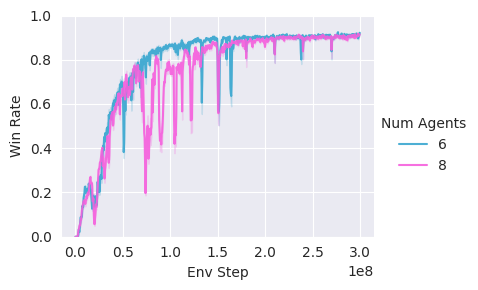

In [130]:
data = measurements.project("""
id as id,
config.seed as seed,
config.homogeneous as homo,
config.total_timesteps as total_timesteps,
config.num_agents as num_agents,
"env_step" as env_step,
"win_rate" as win_rate,
"""
# ).filter("homo is True and id != 'wxm5f0a3' and id != 'cn7tlpts' and id != 'kn42asq1' and id != 'zc0d8usm'")
# ).filter("homo is True")
).filter("homo is True and total_timesteps = 3e08")
# ).filter("homo is True and id != 'a5l2kjnm' and id != 'p6pnp9jk' and id != 'fqrgcyjz' and id != '9c3zc35h' and id != '6walixmb' and id != 'dz8p2ytv'") # and num_agents != 8 and num_agents != 7 and num_agents != 6 and num_agents != 5")

# colours = sns.cubehelix_palette(start=.5, rot=-.5)
# colours = ['mediumblue', 'cornflowerblue', 'darkgreen', 'mediumseagreen', 'rebeccapurple', 'plum', 'maroon', 'darksalmon', 'mediumaquamarine', 'dimgray']      
colours = sns.color_palette("husl", 8)[5:8:2]

g = sns.FacetGrid(
    data.df(),
    # col="homo",
    hue="num_agents",
    palette = colours,
    sharey='row',
    sharex=True,
    aspect=1/0.75,
)

g.map(plot_util.smoothed_lineplot, "env_step", "win_rate", num_std=1, span=0.0015)
g.set_axis_labels("Env Step", "Win Rate")
g.set_titles("")
g.add_legend(title="Num Agents")
g.savefig("../figures/homo_tests_long_one.svg")

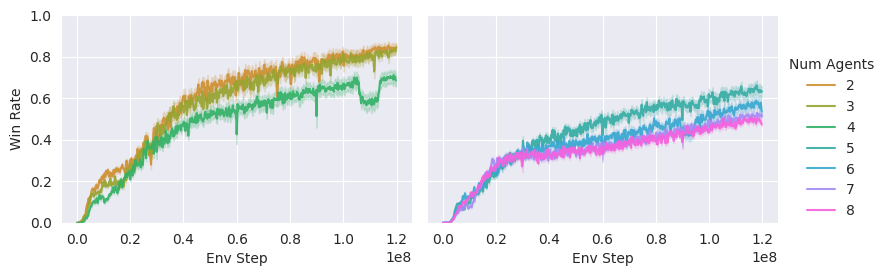

In [131]:
data = measurements.project("""
id as id,
config.seed as seed,
config.homogeneous as homo,
config.num_agents as num_agents,
config.total_timesteps as total_timesteps,
"env_step" as env_step,
"win_rate" as win_rate,
"""
).filter("homo is False and num_agents != 1 and num_agents != 9 and total_timesteps = 1.2e8")

# colours = sns.cubehelix_palette(start=.5, rot=-.5)
# colours = ['cornflowerblue', 'darkgreen', 'mediumseagreen', 'rebeccapurple', 'plum', 'maroon', 'darksalmon', 'mediumaquamarine', 'dimgray']           
colours = sns.color_palette("husl", n_colors=8)[1:]

file_name = "hetero_data_files.csv"
# data.df().to_csv(file_name)
data = pd.read_csv(file_name)
# data = pd.concat((data, pd.read_csv(file_name)))

data["group"] = pd.cut(data['num_agents'], bins=[0, 4, 8], labels=['1-4 agents', '5-8 agents'])

g = sns.FacetGrid(
    # data.df(),
    data,
    col="group",
    hue="num_agents",
    palette = colours,
    sharey='row',
    sharex=True,
    aspect=1/0.75,
)

g.map(plot_util.smoothed_lineplot, "env_step", "win_rate", num_std=1, span=0.0015)
g.set_axis_labels("Env Step", "Win Rate")
g.set_titles("")
g.add_legend(title="Num Agents")
g.savefig("../figures/hetero_tests.svg")

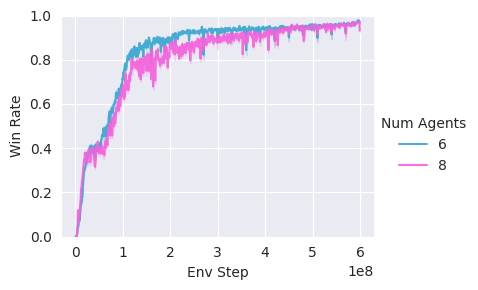

In [132]:
data = measurements.project("""
id as id,
config.seed as seed,
config.homogeneous as homo,
config.num_agents as num_agents,
config.total_timesteps as total_timesteps,
"env_step" as env_step,
"win_rate" as win_rate,
"""
).filter("homo is False and num_agents != 1 and total_timesteps = 6e8 and id != 'l6b8puny'")

# colours = sns.cubehelix_palette(start=.5, rot=-.5)
# colours = ['cornflowerblue', 'darkgreen', 'mediumseagreen', 'rebeccapurple', 'plum', 'maroon', 'darksalmon', 'mediumaquamarine', 'dimgray']           
colours = sns.color_palette("husl", 8)[5:8:2]

file_name = "hetero_long_one_data_files.csv"
# data.df().to_csv(file_name)
data = pd.read_csv(file_name)

g = sns.FacetGrid(
    # data.df(),
    data,
    # col="homo",
    hue="num_agents",
    palette = colours,
    sharey='row',
    sharex=True,
    aspect=1/0.75,
)

g.map(plot_util.smoothed_lineplot, "env_step", "win_rate", num_std=1, span=0.0015)
g.set_axis_labels("Env Step", "Win Rate")
g.set_titles("")
g.add_legend(title="Num Agents")
g.savefig("../figures/hetero_tests_long_one.svg")

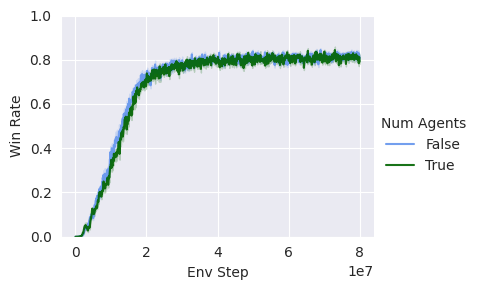

In [71]:
data = measurements.project("""
id as id,
config.seed as seed,
config.homogeneous as homo,
config.num_agents as num_agents,
"env_step" as env_step,
"win_rate" as win_rate,
"""
).filter("num_agents = 1 and id != 'wxm5f0a3' and id != 'cn7tlpts' and id != 'kn42asq1' and id != 'zc0d8usm' and id != 's5ylm058' and id != '0q8epz05'")

# colours = sns.cubehelix_palette(start=.5, rot=-.5)
colours = ['cornflowerblue', 'darkgreen', 'mediumseagreen', 'rebeccapurple', 'plum', 'maroon', 'darksalmon', 'mediumaquamarine', 'dimgray']           

g = sns.FacetGrid(
    data.df(),
    # col="homo",
    hue="homo",
    palette = colours,
    sharey='row',
    sharex=True,
    aspect=1/0.75,
)

g.map(plot_util.smoothed_lineplot, "env_step", "win_rate", num_std=1, span=0.001)
g.set_axis_labels("Env Step", "Win Rate")
g.set_titles("")
g.add_legend(title="Num Agents")
g.savefig("../figures/hom_hetero_single_agent_comparison.png")

In [2]:
data_root = os.path.abspath("./data/wandb")
# group = "new_rnn_comp_tests"
group = "climate_damages_tests"
project = "jamesr-j/multi_agent_climate_pathways"

if not os.path.exists(os.path.join(data_root, group)):
# if os.path.exists(os.path.join(data_root, group)):
    api = wandb.Api()
    runs = api.runs(project, filters={"group": group})
    assert runs
    save_dir = os.path.join(data_root, group)
    os.makedirs(save_dir, exist_ok=True)
    data_util.write_runs_to_parquet(runs, save_dir)
    # for run in runs:
    #     table = data_util._run_to_arrow_table(run, save_metadata=True)
    #     save_path = os.path.join(save_dir, f"{run.id}.parquet")
    #     print("Saving", save_path)
    #     pq.write_table(table, save_path)

file_glob = os.path.join(data_root, group)  # , "*.parquet")
# file_glob = os.path.join(data_root, "1 agents PPO")  # , "*.parquet")

def read_wandb_metadata(path: os.PathLike, filename: bool = True):
    parquet_metadata = pq.read_metadata(path)
    wandb_metadata = json.loads(parquet_metadata.metadata[b"wandb"])
    if filename:
        wandb_metadata["filename"] = os.fspath(path)
    return wandb_metadata

all_dicts = []
for file in os.listdir(file_glob):
    meta_step = data_util.read_wandb_metadata(os.path.join(file_glob, file))
    all_dicts.append(meta_step)
meta = pd.DataFrame(all_dicts)

### below is dodgy workaround when differeing lengths config, to keep the struct datatype in duckdb
max_keys = 0
max_keys_id = None
for row_id in range(len(meta["config"])):
    length = len(meta["config"][row_id])
    if length > max_keys:
        max_keys = length
        max_keys_id = row_id
all_keys = meta["config"][max_keys_id].keys()

def update_dict(d):
  return {key: d.get(key, np.nan) for key in all_keys}

meta["config"] = meta["config"].apply(update_dict)
### and here it ends

# meta = data_util.read_wandb_metadata(file_glob)  # TODO this is the original
metrics = data_util.read_wandb_history(os.path.join(file_glob, "*.parquet"))
# measurements = duckdb.from_df(meta.loc[:, ["id", *meta.attrs["sweep_vars"]]]).join(metrics, "id")  # TODO the original

measurements = duckdb.from_df(meta.loc[:, ["id", "config"]]).join(metrics, "id")
# measurements = duckdb.from_df(meta.loc[:, ["id"]]).join(metrics, "id")
# print(measurements)

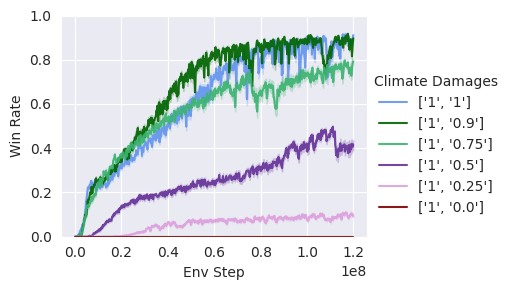

In [3]:
data = measurements.project("""
id as id,
config.seed as seed,
config.num_agents as num_agents,
config.total_timesteps as total_timesteps,
config.climate_damages as climate_damages,
"env_step" as env_step,
"win_rate" as win_rate,
"returns_agent_0" as returns_agent_0,
"returns_agent_1" as returns_agent_1
"""
)  # .filter("homo is False and num_agents != 1 and total_timesteps = 6e8 and id != 'l6b8puny'")

inter_data = data.df()
inter_data["climate_damages"] = inter_data["climate_damages"].astype(str)  # conversion as reward_type is a list

# colours = sns.cubehelix_palette(start=.5, rot=-.5)
colours = ['cornflowerblue', 'darkgreen', 'mediumseagreen', 'rebeccapurple', 'plum', 'maroon', 'darksalmon', 'mediumaquamarine', 'dimgray']           
# colours = sns.color_palette("husl", 8)[5:8:2]

g = sns.FacetGrid(
    inter_data,
    # col="returns_agent_0",
    hue="climate_damages",
    palette = colours,
    sharey='row',
    sharex=True,
    aspect=1/0.75,
    hue_order=["['1', '1']", "['1', '0.9']", "['1', '0.75']", "['1', '0.5']", "['1', '0.25']", "['1', '0.0']"]
)

g.map(plot_util.smoothed_lineplot, "env_step", "win_rate", num_std=1, span=0.0015)
g.set_axis_labels("Env Step", "Win Rate")
g.set_titles("")
g.add_legend(title="Climate Damages")
g.savefig("../figures/climate_damages.svg")

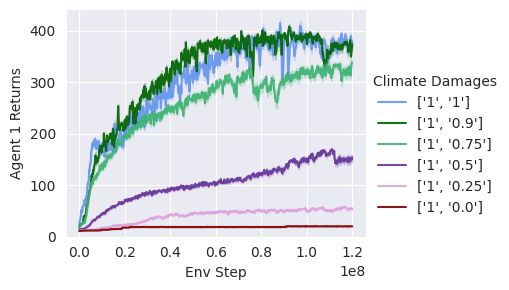

In [3]:
# TODO plot_util has a set y_lim featuere
data = measurements.project("""
id as id,
config.seed as seed,
config.num_agents as num_agents,
config.total_timesteps as total_timesteps,
config.climate_damages as climate_damages,
"env_step" as env_step,
"returns_agent_0" as returns_agent_0,
"""
)  # .filter("homo is False and num_agents != 1 and total_timesteps = 6e8 and id != 'l6b8puny'")

inter_data = data.df()
inter_data["climate_damages"] = inter_data["climate_damages"].astype(str)  # conversion as reward_type is a list

# colours = sns.cubehelix_palette(start=.5, rot=-.5)
colours = ['cornflowerblue', 'darkgreen', 'mediumseagreen', 'rebeccapurple', 'plum', 'maroon', 'darksalmon', 'mediumaquamarine', 'dimgray']           
# colours = sns.color_palette("husl", 8)[5:8:2]

g = sns.FacetGrid(
    inter_data,
    # col="returns_agent_0",
    hue="climate_damages",
    palette = colours,
    sharey='row',
    sharex=True,
    aspect=1/0.75,
    hue_order=["['1', '1']", "['1', '0.9']", "['1', '0.75']", "['1', '0.5']", "['1', '0.25']", "['1', '0.0']"]
)

g.map(plot_util.smoothed_lineplot, "env_step", "returns_agent_0", num_std=1, span=0.0015)
g.set_axis_labels("Env Step", "Agent 1 Returns")
g.set_titles("")
g.add_legend(title="Climate Damages")
g.savefig("../figures/climate_damages_agent_1_returns.svg")

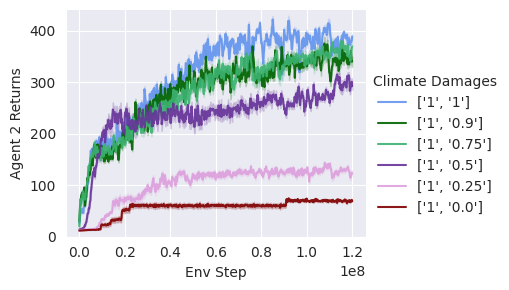

In [4]:
data = measurements.project("""
id as id,
config.seed as seed,
config.num_agents as num_agents,
config.total_timesteps as total_timesteps,
config.climate_damages as climate_damages,
"env_step" as env_step,
"returns_agent_1" as returns_agent_1
"""
)  # .filter("homo is False and num_agents != 1 and total_timesteps = 6e8 and id != 'l6b8puny'")

inter_data = data.df()
inter_data["climate_damages"] = inter_data["climate_damages"].astype(str)  # conversion as reward_type is a list

# colours = sns.cubehelix_palette(start=.5, rot=-.5)
colours = ['cornflowerblue', 'darkgreen', 'mediumseagreen', 'rebeccapurple', 'plum', 'maroon', 'darksalmon', 'mediumaquamarine', 'dimgray']           
# colours = sns.color_palette("husl", 8)[5:8:2]

g = sns.FacetGrid(
    inter_data,
    # col="returns_agent_0",
    hue="climate_damages",
    palette = colours,
    sharey='row',
    sharex=True,
    aspect=1/0.75,
    hue_order=["['1', '1']", "['1', '0.9']", "['1', '0.75']", "['1', '0.5']", "['1', '0.25']", "['1', '0.0']"]
)

g.map(plot_util.smoothed_lineplot, "env_step", "returns_agent_1", num_std=1, span=0.0015)
g.set_axis_labels("Env Step", "Agent 2 Returns")
g.set_titles("")
g.add_legend(title="Climate Damages")
g.savefig("../figures/climate_damages_agent_2_returns.svg")

In [5]:
data_root = os.path.abspath("./data/wandb")
# group = "comp_sweep"
group = "new_rnn_comp_tests"
project = "jamesr-j/multi_agent_climate_pathways"

if os.path.exists(os.path.join(data_root, group)):
    api = wandb.Api()
    runs = api.runs(project, filters={"group": group})
    assert runs
    save_dir = os.path.join(data_root, group)
    os.makedirs(save_dir, exist_ok=True)
    data_util.write_runs_to_parquet(runs, save_dir)
    # for run in runs:
    #     table = data_util._run_to_arrow_table(run, save_metadata=True)
    #     save_path = os.path.join(save_dir, f"{run.id}.parquet")
    #     print("Saving", save_path)
    #     pq.write_table(table, save_path)

file_glob = os.path.join(data_root, group)  # , "*.parquet")
# file_glob = os.path.join(data_root, "1 agents PPO")  # , "*.parquet")

def read_wandb_metadata(path: os.PathLike, filename: bool = True):
    parquet_metadata = pq.read_metadata(path)
    wandb_metadata = json.loads(parquet_metadata.metadata[b"wandb"])
    if filename:
        wandb_metadata["filename"] = os.fspath(path)
    return wandb_metadata

all_dicts = []
for file in os.listdir(file_glob):
    meta_step = data_util.read_wandb_metadata(os.path.join(file_glob, file))
    all_dicts.append(meta_step)
meta = pd.DataFrame(all_dicts)

### below is dodgy workaround when differeing lengths config, to keep the struct datatype in duckdb
max_keys = 0
max_keys_id = None
for row_id in range(len(meta["config"])):
    length = len(meta["config"][row_id])
    if length > max_keys:
        max_keys = length
        max_keys_id = row_id
all_keys = meta["config"][max_keys_id].keys()

def update_dict(d):
  return {key: d.get(key, np.nan) for key in all_keys}

meta["config"] = meta["config"].apply(update_dict)
### and here it ends

# meta = data_util.read_wandb_metadata(file_glob)  # TODO this is the original
metrics = data_util.read_wandb_history(os.path.join(file_glob, "*.parquet"))
# measurements = duckdb.from_df(meta.loc[:, ["id", *meta.attrs["sweep_vars"]]]).join(metrics, "id")  # TODO the original

measurements = duckdb.from_df(meta.loc[:, ["id", "config"]]).join(metrics, "id")
# measurements = duckdb.from_df(meta.loc[:, ["id"]]).join(metrics, "id")

Skip writing runs.


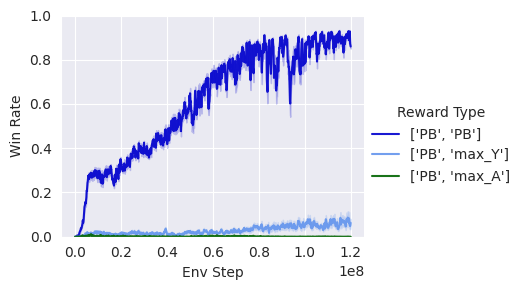

In [138]:
data = measurements.project("""
config.reward_type as reward_type,
config.num_agents as num_agents,
config.num_loops as num_loops, 
"env_step" as env_step,
"win_rate" as win_rate,
"""
).filter("num_agents = 2 and num_loops = 20")

inter_data = data.df()
inter_data["reward_type"] = inter_data["reward_type"].astype(str)  # conversion as reward_type is a list

# colours = sns.cubehelix_palette(start=.5, rot=-.5)
colours = ['mediumblue', 'cornflowerblue', 'darkgreen', 'mediumseagreen', 'rebeccapurple', 'plum', 'maroon', 'darksalmon', 'mediumaquamarine', 'dimgray']          

g = sns.FacetGrid(
    inter_data,
    # col="num_agents",
    hue="reward_type",
    hue_order = ["['PB', 'PB']", "['PB', 'max_Y']", "['PB', 'max_A']"],
    palette = colours,
    sharey='row',
    sharex=True,
    aspect=1/0.75,
)

g.map(plot_util.smoothed_lineplot, "env_step", "win_rate", num_std=1, span=0.001)
g.set_axis_labels("Env Step", "Win Rate")
g.set_titles("")
g.add_legend(title="Reward Type")
# g.add_legend(title="Reward Type", legend_data = {"['PB', 'PB']": "0", "['PB', 'max_Y']": "1", "['PB', 'max_A']": "2"})
g.savefig("../figures/comp_tests_2_agents.svg")

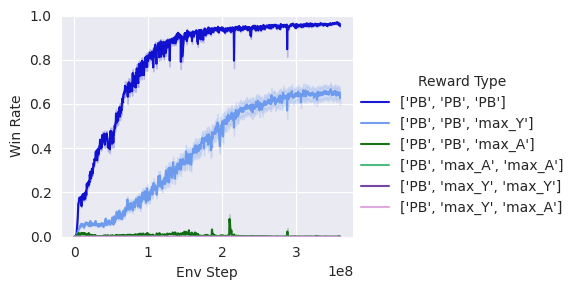

In [14]:
data = measurements.project("""
config.reward_type as reward_type,
config.num_agents as num_agents,
config.num_loops as num_loops,
config.total_timesteps as timesteps,
"env_step" as env_step,
"win_rate" as win_rate,
"""
).filter("num_agents = 3 and timesteps = 3.6e8")

file_name = "3_agents_data_files.csv"
# data.df().to_csv(file_name)
inter_data = pd.read_csv(file_name)
inter_data["reward_type"] = inter_data["reward_type"].astype(str)  # conversion as reward_type is a list

# colours = sns.cubehelix_palette(start=.5, rot=-.5)
colours = ['mediumblue', 'cornflowerblue', 'darkgreen', 'mediumseagreen', 'rebeccapurple', 'plum', 'maroon', 'darksalmon', 'mediumaquamarine', 'dimgray']    

g = sns.FacetGrid(
    inter_data,
    # col="num_agents",
    hue="reward_type",
    hue_order = ["['PB', 'PB', 'PB']", "['PB', 'PB', 'max_Y']", "['PB', 'PB', 'max_A']", "['PB', 'max_A', 'max_A']", "['PB', 'max_Y', 'max_Y']", "['PB', 'max_Y', 'max_A']"],
    palette = colours,
    sharey='row',
    sharex=True,
    aspect=1/0.75,
)

g.map(plot_util.smoothed_lineplot, "env_step", "win_rate", num_std=1, span=0.001)
g.set_axis_labels("Env Step", "Win Rate")
g.set_titles("")
g.add_legend(title="Reward Type")
g.savefig("../figures/comp_tests_3_agents.svg")

In [ ]:
data = measurements.project(
    """
"config.dataset.name" as dataset,
"config.num_offline_steps" as num_offline_steps,
"learner/learner_steps" as learner_steps,
(1 - "learner/online_fraction") as offline_fraction,
"""
).filter("offline_fraction is not NULL")

g = sns.FacetGrid(
    data.df(),
    col="dataset",
    hue="num_offline_steps",
    sharey='row',
    sharex=True,
    aspect=1/0.75,
)
g.map(plot_util.smoothed_lineplot, "learner_steps", "offline_fraction")
g.add_legend()

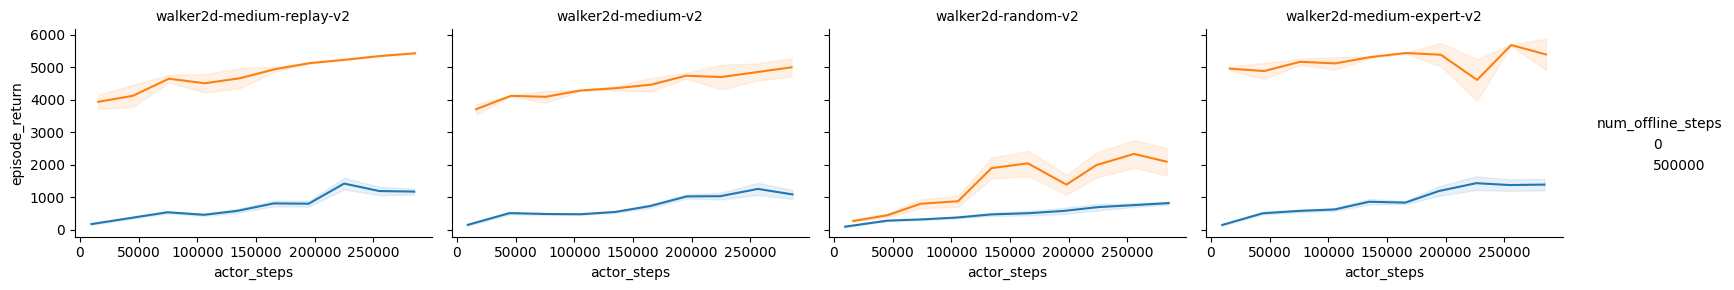

In [32]:
data = measurements.project(
    """
"config.dataset.name" as dataset,
"config.num_offline_steps" as num_offline_steps,
"actor/actor_steps" as actor_steps,
"actor/episode_return" as episode_return,
"""
).filter("actor_steps is not NULL")

g = sns.FacetGrid(
    data.df(),
    col="dataset",
    hue="num_offline_steps",
    sharey='row',
    sharex=True,
    aspect=1/0.75,
)
g.set_titles("{col_name}")
g.add_legend()
g.map(plot_util.smoothed_lineplot, "actor_steps", "episode_return")
